
# Hospital Patient Data Analysis

## Objective
Analyze hospital patient records to identify trends in patient demographics, medical conditions, treatment costs, hospital performance, and patient outcomes. The insights will support data-driven decision-making and improve healthcare operations.

### Tools Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Google Colab



In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df=pd.read_csv('/content/hospital data analysis.csv')

Data Quality Assessment

In [ ]:
df.head()

,Patient_ID,Age,Gender,Condition,Procedure,Cost,Length_of_Stay,Readmission,Outcome,Satisfaction
0,1,45,Female,Heart Disease,Angioplasty,15000,5,No,Recovered,4
1,2,60,Male,Diabetes,Insulin Therapy,2000,3,Yes,Stable,3
2,3,32,Female,Fractured Arm,X-Ray and Splint,500,1,No,Recovered,5
3,4,75,Male,Stroke,CT Scan and Medication,10000,7,Yes,Stable,2
4,5,50,Female,Cancer,Surgery and Chemotherapy,25000,10,No,Recovered,4


In [ ]:
df.tail()

,Patient_ID,Age,Gender,Condition,Procedure,Cost,Length_of_Stay,Readmission,Outcome,Satisfaction
979,996,68,Male,Hypertension,Medication and Counseling,1000,70,No,Stable,4
980,997,45,Female,Appendicitis,Appendectomy,8000,72,No,Recovered,3
981,998,40,Male,Fractured Leg,Cast and Physical Therapy,3000,72,No,Recovered,4
982,999,78,Female,Heart Attack,Cardiac Catheterization,18000,74,Yes,Stable,2
983,1000,25,Male,Allergic Reaction,Epinephrine Injection,100,68,No,Recovered,5


In [ ]:
df.describe()

,Patient_ID,Age,Cost,Length_of_Stay,Satisfaction
count,984.000000,984.000000,984.000000,984.000000,984.000000
mean,500.329268,53.754065,8367.479675,37.663618,3.598577
std,288.979531,14.941135,7761.990976,19.595805,0.883002
min,1.000000,25.000000,100.000000,1.000000,2.000000
25%,250.750000,45.000000,1000.000000,21.000000,3.000000
50%,500.500000,55.000000,6000.000000,38.000000,4.000000
75%,750.250000,65.000000,15000.000000,54.250000,4.000000
max,1000.000000,78.000000,25000.000000,76.000000,5.000000


In [ ]:
df.shape

(984, 10)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 984 entries, 0 to 983
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Patient_ID      984 non-null    int64 
 1   Age             984 non-null    int64 
 2   Gender          984 non-null    object
 3   Condition       984 non-null    object
 4   Procedure       984 non-null    object
 5   Cost            984 non-null    int64 
 6   Length_of_Stay  984 non-null    int64 
 7   Readmission     984 non-null    object
 8   Outcome         984 non-null    object
 9   Satisfaction    984 non-null    int64 
dtypes: int64(5), object(5)
memory usage: 77.0+ KB


In [ ]:
df.columns

Index(['Patient_ID', 'Age', 'Gender', 'Condition', 'Procedure', 'Cost',
       'Length_of_Stay', 'Readmission', 'Outcome', 'Satisfaction'],
      dtype='object')

In [ ]:
df.sample(5)

,Patient_ID,Age,Gender,Condition,Procedure,Cost,Length_of_Stay,Readmission,Outcome,Satisfaction
614,625,28,Male,Allergic Reaction,Epinephrine Injection,100,42,No,Recovered,5
538,548,40,Male,Fractured Leg,Cast and Physical Therapy,3000,42,No,Recovered,4
617,628,35,Female,Childbirth,Delivery and Postnatal Care,12000,44,No,Recovered,4
945,961,48,Female,Heart Disease,Angioplasty,15000,69,Yes,Recovered,4
605,616,55,Female,Heart Disease,Angioplasty,15000,46,Yes,Recovered,3


In [ ]:
df.isnull().sum()

,0
Patient_ID,0
Age,0
Gender,0
Condition,0
Procedure,0
Cost,0
Length_of_Stay,0
Readmission,0
Outcome,0
Satisfaction,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
for col in df.columns:
    print(col)
    print(df[col].unique())
    print("-"*50)

Patient_ID
[   1    2    3    4    5    6    7    8    9   10   11   12   13   14
   15   16   17   18   19   20   21   22   23   24   25   26   27   28
   29   30   31   32   33   34   35   36   37   38   39   40   41   42
   43   44   45   46   47   48   49   50   51   52   53   54   55   56
   57   58   59   61   62   63   64   65   66   67   68   69   70   71
   72   73   74   75   76   77   78   79   80   81   82   83   84   85
   86   87   88   89   90   91   92   93   94   95   96   97   98   99
  100  101  102  103  104  105  106  107  108  109  110  111  112  113
  114  115  116  117  118  119  120  122  123  124  125  126  127  128
  129  130  131  132  133  134  135  136  137  138  139  140  141  142
  143  144  145  146  147  148  149  150  151  152  153  154  155  156
  157  158  159  160  161  162  163  164  165  166  167  168  169  170
  171  172  173  174  175  176  177  178  179  180  181  183  184  185
  186  187  188  189  190  191  192  193  194  195  196  197  198 

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Patient_ID,984.0,500.329268,288.979531,1.0,250.75,500.5,750.25,1000.0
Age,984.0,53.754065,14.941135,25.0,45.00,55.0,65.00,78.0
Cost,984.0,8367.479675,7761.990976,100.0,1000.00,6000.0,15000.00,25000.0
Length_of_Stay,984.0,37.663618,19.595805,1.0,21.00,38.0,54.25,76.0
Satisfaction,984.0,3.598577,0.883002,2.0,3.00,4.0,4.00,5.0


In [ ]:
df.describe(include='object')

,Gender,Condition,Procedure,Readmission,Outcome
count,984,984,984,984,984
unique,2,15,15,2,2
top,Female,Fractured Leg,Cast and Physical Therapy,No,Recovered
freq,524,67,67,720,591


In [ ]:
df.dtypes

,0
Patient_ID,int64
Age,int64
Gender,object
Condition,object
Procedure,object
Cost,int64
Length_of_Stay,int64
Readmission,object
Outcome,object
Satisfaction,int64


Statistical Analysis

In [ ]:
df.nunique()

,0
Patient_ID,984
Age,22
Gender,2
Condition,15
Procedure,15
Cost,15
Length_of_Stay,76
Readmission,2
Outcome,2
Satisfaction,4


In [ ]:
df.median(numeric_only=True)

,0
Patient_ID,500.5
Age,55.0
Cost,6000.0
Length_of_Stay,38.0
Satisfaction,4.0


In [ ]:
df.mode()

,Patient_ID,Age,Gender,Condition,Procedure,Cost,Length_of_Stay,Readmission,Outcome,Satisfaction
0,1,55.0,Female,Fractured Leg,Cardiac Catheterization,3000.0,10.0,No,Recovered,4.0
1,2,NaN,NaN,Heart Attack,Cast and Physical Therapy,18000.0,11.0,NaN,NaN,NaN
2,3,NaN,NaN,NaN,NaN,NaN,12.0,NaN,NaN,NaN
3,4,NaN,NaN,NaN,NaN,NaN,14.0,NaN,NaN,NaN
4,5,NaN,NaN,NaN,NaN,NaN,16.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
979,996,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
980,997,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
981,998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
982,999,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.var(numeric_only=True)

,0
Patient_ID,8.350917e+04
Age,2.232375e+02
Cost,6.024850e+07
Length_of_Stay,3.839956e+02
Satisfaction,7.796928e-01


In [ ]:
df.std(numeric_only=True)

,0
Patient_ID,288.979531
Age,14.941135
Cost,7761.990976
Length_of_Stay,19.595805
Satisfaction,0.883002


In [ ]:
df.skew(numeric_only=True)

,0
Patient_ID,-0.000172
Age,-0.244515
Cost,0.721300
Length_of_Stay,0.001134
Satisfaction,-0.305531


In [ ]:
df.kurt(numeric_only=True)

,0
Patient_ID,-1.200055
Age,-0.868534
Cost,-0.721782
Length_of_Stay,-1.159031
Satisfaction,-0.613206


Outlier Detection

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

Univariate Analysis

<Axes: xlabel='Age'>

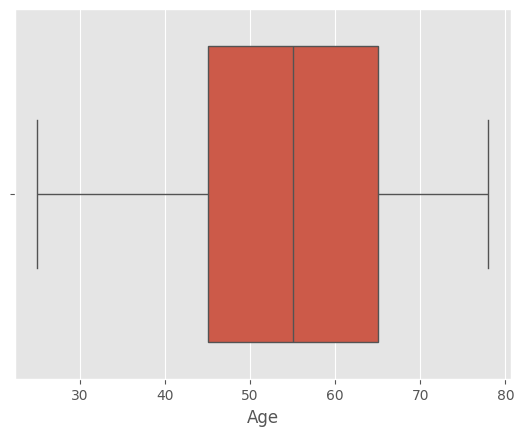

In [ ]:
sns.boxplot(x=df['Age'])

In [ ]:
Q1=df['Age'].quantile(.25)

Q3=df['Age'].quantile(.75)

IQR=Q3-Q1

lower=Q1-1.5*IQR

upper=Q3+1.5*IQR

<Axes: xlabel='Gender', ylabel='count'>

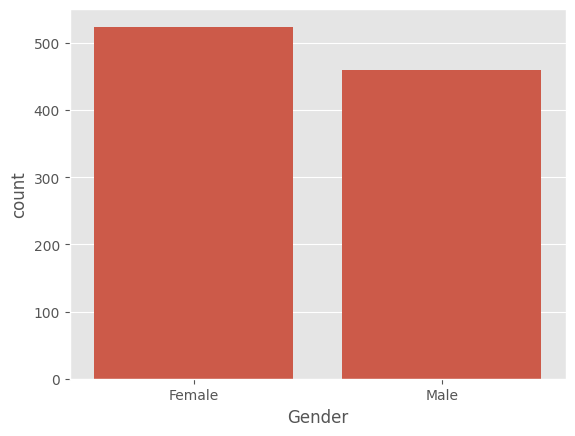

In [ ]:
df['Gender'].value_counts()

sns.countplot(data=df,x='Gender')

<Axes: xlabel='Age', ylabel='Count'>

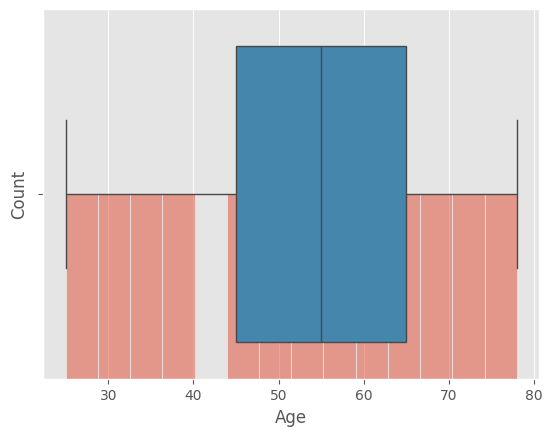

In [ ]:
sns.histplot(df['Age'],kde=True)

sns.boxplot(x=df['Age'])

Bivarient Analysis


<Axes: xlabel='Age', ylabel='Cost'>

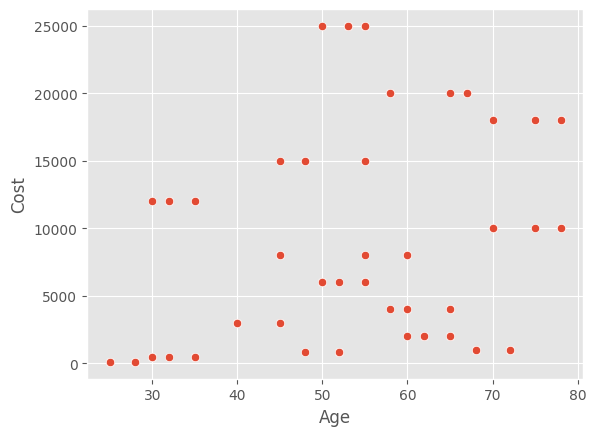

In [ ]:
sns.scatterplot(data=df,
                x='Age',
                y='Cost')

<Axes: xlabel='Gender', ylabel='Cost'>

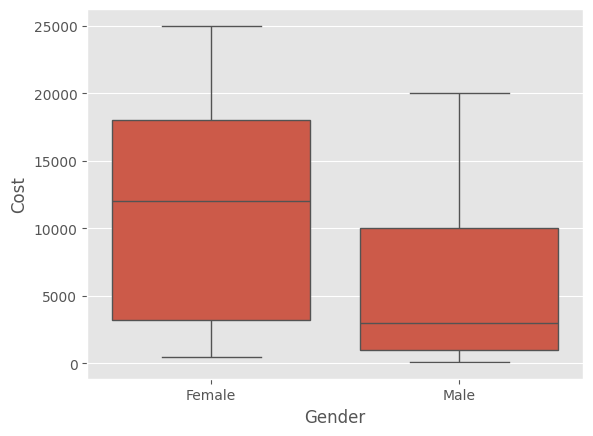

In [ ]:
sns.boxplot(data=df,
            x='Gender',
            y='Cost')

In [ ]:
pd.crosstab(df['Gender'],
            df['Outcome'])

Outcome,Recovered,Stable
Gender,,
Female,328,196
Male,263,197


Correlation


In [ ]:
corr=df.corr(numeric_only=True)

corr

,Patient_ID,Age,Cost,Length_of_Stay,Satisfaction
Patient_ID,1.000000,-0.002935,-0.004168,0.989917,0.005263
Age,-0.002935,1.000000,0.303816,0.075080,-0.750429
Cost,-0.004168,0.303816,1.000000,0.114206,-0.469658
Length_of_Stay,0.989917,0.075080,0.114206,1.000000,-0.080891
Satisfaction,0.005263,-0.750429,-0.469658,-0.080891,1.000000


<Axes: >

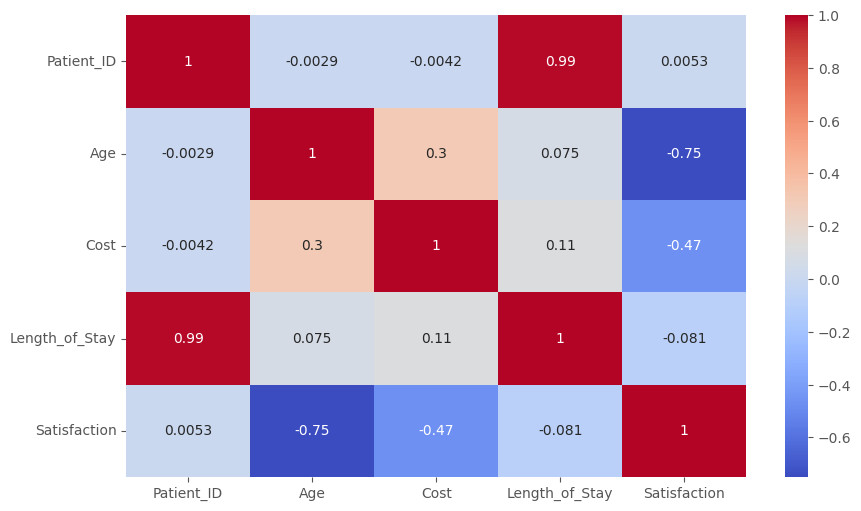

In [ ]:
plt.figure(figsize=(10,6))

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm')

GroupBy Analysis

In [ ]:
df.groupby('Gender')['Cost'].mean()

,Cost
Gender,
Female,10458.015267
Male,5986.086957


In [ ]:
df.groupby('Condition')['Age'].mean()

,Age
Condition,
Allergic Reaction,26.454545
Appendicitis,52.651515
Cancer,53.924242
Childbirth,33.446154
Diabetes,63.400000
Fractured Arm,32.530303
Fractured Leg,42.462687
Heart Attack,76.402985
Heart Disease,51.507692


In [ ]:
df.groupby(['Gender','Outcome'])['Cost'].mean()

Gender  Outcome  
Female  Recovered    12091.463415
        Stable        7724.489796
Male    Recovered     7215.209125
        Stable        4345.177665
Name: Cost, dtype: float64

In [ ]:
df['Age_Group']=pd.cut(df['Age'],
                       bins=[0,18,35,50,65,100],
                       labels=['Child','Young','Adult','Senior','Old'])

In [ ]:
df.to_csv("cleaned_data.csv",
          index=False)

In [ ]:
from google.colab import files

files.download("cleaned_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>